# SAR sobre la Predicción Real de Altiplano/No-Altiplano (v2, corregido)

## Por qué existe este notebook

**Corrección pedida por el usuario:** `10_SAR_altiplanos_v2.ipynb` ajusta SLX/SEM/SAR-Lag
sobre `Altitud_X` (continua) usando únicamente los 491 polígonos de altiplano ya
delimitados — es decir, **nunca evalúa si el modelo distingue Altiplano de No-Altiplano**,
porque todas sus 491 filas SON altiplanos. Aquí se corrige eso: se evalúa la familia SAR
sobre la **clasificación binaria real** (Altiplano=1 / No-Altiplano=0) usando la **capa de
celdas** (píxeles del ráster), el mismo problema que resuelve
`03_regresion_no_espacial_raster_v2.ipynb`.

**Este notebook NO modifica `10_SAR_altiplanos_v2.ipynb`** — queda intacto como el análisis
de la relación Altitud~Pendiente+Relieve dentro de los altiplanos ya conocidos. Este es un
notebook nuevo y separado con un objetivo distinto: ¿la extensión espacial tipo SAR mejora
la **predicción de qué es altiplano**?

## Limitación técnica que obliga a un cambio de método

`spreg.GM_Lag` y `spreg.GM_Error_Het` (los estimadores SAR-Lag/SEM usados en
`10_SAR_altiplanos_v2.ipynb`) **requieren una variable respuesta continua** — no se pueden
aplicar directamente a `Altiplano` (0/1). Para variables binarias, `spreg` ofrece
`spreg.Probit`, que sí admite dos extensiones espaciales:

1. **SLX-Probit** (rezago espacial de los PREDICTORES): se agrega, para cada píxel, el
   promedio de Altitud/Pendiente/Relieve de sus 8 vecinos inmediatos (contigüidad Queen)
   como predictores adicionales. Esto es una extensión directa y sin ambigüedad del
   SLX ya usado en `10_SAR_altiplanos_v2.ipynb`.
2. **Autologístico** (análogo binario de SAR-Lag): en vez de una variable continua con un
   término autorregresivo ρWy estimado por GMM (que no existe para variables binarias en
   `spreg`), la extensión estándar en la literatura (Besag, 1972) agrega el **rezago
   espacial de la propia variable respuesta** (la proporción de vecinos que SÍ son
   Altiplano) como predictor adicional — el análogo discreto más directo del término Wy
   de SAR-Lag.

**Aviso importante que se descubre y diagnostica en este notebook:** la versión "ingenua"
del autologístico (usar el rezago de la etiqueta VERDADERA de los vecinos) da un AUC casi
perfecto (~0.9999) — pero esto **no es un modelo útil**, es una tautología: los altiplanos
son polígonos contiguos que cubren muchos píxeles vecinos, así que saber que el 95% de los
vecinos de un píxel son Altiplano ya casi responde la pregunta por sí solo. Se diagnostica
esto explícitamente (igual que se hizo con la paridad de AUC en
`05_modelo_jerarquico_cordilleras_v2.ipynb`) y se corrige con una versión de **dos etapas**:
el rezago espacial se calcula sobre la PROBABILIDAD PREDICHA por un modelo base (que solo
usa Altitud/Pendiente/Relieve, nunca la etiqueta verdadera de los vecinos) — así el modelo
sigue siendo evaluable de forma honesta en datos nuevos.

## Qué se calculó ANTES (en `10_SAR_altiplanos_v2.ipynb`) vs. AHORA (este notebook)

| | Antes (`10_SAR_altiplanos_v2.ipynb`) | Ahora (este notebook) |
|---|---|---|
| Variable respuesta | `Altitud_X` (continua) | `Altiplano` (binaria: 0/1) |
| Unidad de análisis | 491 polígonos de altiplano (centroides) | Píxeles del ráster (muestra de 300,000, igual que `03_v2`) |
| Todas las filas son Altiplano=1 | Sí (no evalúa clasificación) | No — 15.1% Altiplano=1, 84.9% No-altiplano=0 |
| Estimador | `spreg.GM_Lag` / `spreg.GM_Error_Het` (GMM, requieren Y continua) | `spreg.Probit` (con `slx` manual y autologístico) |
| Qué mide | Cuánto se relacionan Altitud/Pendiente/Relieve DENTRO de zonas ya sabidas como altiplano | Si añadir estructura espacial mejora la PREDICCIÓN de si un píxel cualquiera es o no altiplano |


## [0] Configuración


In [1]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import rasterio                                    # lectura/escritura de rasters (.tif)
from rasterio.warp import reproject, Resampling    # reproyectar/alinear un raster a otra grilla
from rasterio.transform import array_bounds        # límites geográficos de la grilla (para extent)
import geopandas as gpd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.ndimage import convolve   # convolución 2D = base del rezago espacial sobre el raster
from scipy.stats import norm         # Phi (CDF normal) para la función de enlace probit

from sklearn.model_selection import train_test_split   # partición estratificada train/test
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

import spreg   # spreg.Probit = regresión probit espacial

warnings.filterwarnings("ignore")

CARPETA_RASTER = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Raster\50m_UTM\Analisis"
CARPETA_RESULTADOS = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados"
CARPETA_FIGURAS = os.path.join(CARPETA_RESULTADOS, "10_SAR_altiplanos_clasificacion_v2")
os.makedirs(CARPETA_FIGURAS, exist_ok=True)

SEMILLA = 42
N_MUESTRA = 300_000   # nº de píxeles muestreados para ajustar (el raster completo es ~50M px)
np.random.seed(SEMILLA)

print(f"Carpeta de figuras de este notebook: {CARPETA_FIGURAS}")

Carpeta de figuras de este notebook: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\10_SAR_altiplanos_clasificacion_v2


## [1] Cargar el DEM (grilla de referencia) y alinear `Altiplanos.tif`

Mismo procedimiento que `03_regresion_no_espacial_raster_v2.ipynb`: el DEM define la
extensión de trabajo, y `Altiplanos.tif` se remuestrea a su grilla exacta con interpolación
vecino-más-cercano (apropiada para una máscara categórica).


In [2]:
t_inicio = time.time()

# DEM (altitud) = raster de REFERENCIA: fija transform, CRS y forma para alinear todo lo demás.
with rasterio.open(f"{CARPETA_RASTER}\\DEM_NA_50.tif") as src:
    altitud = src.read(1).astype(np.float32)   # banda 1 como float32
    dem_nodata = src.nodata                     # valor que marca "sin dato"
    ref_transform = src.transform               # afín píxel->coordenadas
    ref_crs = src.crs
    ref_shape = (src.height, src.width)

# Pendiente y Relieve se releen forzando out_shape=ref_shape (remuestreo a la grilla del DEM).
with rasterio.open(f"{CARPETA_RASTER}\\Slp_NA_50.tif") as src:
    pendiente = src.read(1, out_shape=ref_shape).astype(np.float32)
    nodata_pend = src.nodata

with rasterio.open(f"{CARPETA_RASTER}\\Rel_NA_5.tif") as src:
    relieve = src.read(1, out_shape=ref_shape).astype(np.float32)
    nodata_rel = src.nodata

# Altiplanos.tif = etiqueta verdadera (1=altiplano). Puede venir en otra grilla -> se reproyecta.
with rasterio.open(f"{CARPETA_RASTER}\\Altiplanos.tif") as src:
    altiplano_original = src.read(1)
    altiplano_nodata = src.nodata
    altiplano_transform = src.transform
    altiplano_crs = src.crs

altiplano_alineado = np.zeros(ref_shape, dtype=np.uint8)
# reproject con Resampling.nearest (vecino más cercano = correcto para etiquetas categóricas).
reproject(
    source=altiplano_original, destination=altiplano_alineado,
    src_transform=altiplano_transform, src_crs=altiplano_crs,
    dst_transform=ref_transform, dst_crs=ref_crs,
    resampling=Resampling.nearest, src_nodata=altiplano_nodata, dst_nodata=0,
)

# Máscara de píxeles válidos = con dato en las TRES capas predictoras simultáneamente.
mascara_valida = (altitud != dem_nodata) & (pendiente != nodata_pend) & (relieve != nodata_rel)
print(f"Pixeles validos (DEM + Pendiente + Relieve): {mascara_valida.sum():,} de {mascara_valida.size:,} "
      f"({100*mascara_valida.sum()/mascara_valida.size:.1f}%)")

Pixeles validos (DEM + Pendiente + Relieve): 24,783,966 de 50,351,184 (49.2%)


## [2] Exploración de datos

**Qué se busca:** N de píxeles válidos, balance de clases y distribución de los 3
predictores (Altitud, Pendiente, Relieve_5) por clase — igual que en `03_v2`, pero
limitando el conjunto a estos 3 predictores base (en vez de los 18 de `03_v2`) para
mantener tratables los cálculos de rezago espacial y, más adelante, la calibración de
ancho de banda de GWR en `13_MGWR_altiplanos_clasificacion_v2.ipynb` — el mismo conjunto de
variables se reutiliza en ambos notebooks corregidos para comparabilidad directa.


Proporcion Altiplano=1: 15.1%  (No-altiplano=0: 84.9%)
Area valida: 61,960 km2


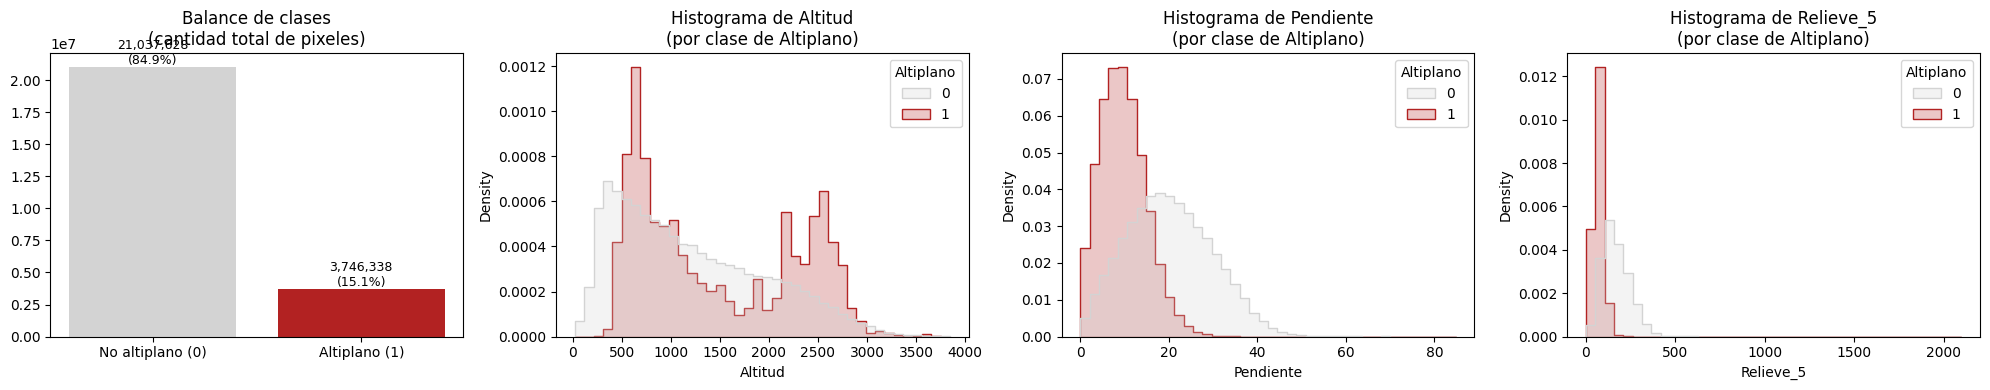

In [3]:
# y verdadera del mapa: es Altiplano (=1) sólo donde la etiqueta==1 Y el píxel es válido.
y_altiplano_mapa = (altiplano_alineado == 1) & mascara_valida
n_altiplano = y_altiplano_mapa.sum()
n_valido = mascara_valida.sum()

print(f"Proporcion Altiplano=1: {100*n_altiplano/n_valido:.1f}%  (No-altiplano=0: {100*(1-n_altiplano/n_valido):.1f}%)")
# Área válida = nº de píxeles válidos * (tamaño de píxel)^2. transform.a = ancho de píxel (50 m).
print(f"Area valida: {n_valido * (abs(ref_transform.a)**2) / 1e6:,.0f} km2")

# Muestra de 200k píxeles válidos SÓLO para los histogramas (más rápido que graficar todos).
filas, cols = np.where(mascara_valida)   # índices (fila,col) de cada píxel válido
idx_hist = np.random.choice(len(filas), size=200_000, replace=False)
fh, ch = filas[idx_hist], cols[idx_hist]
tabla_hist = pd.DataFrame({
    "Altitud": altitud[fh, ch], "Pendiente": pendiente[fh, ch], "Relieve_5": relieve[fh, ch],
    "Altiplano": y_altiplano_mapa[fh, ch].astype(int),
})

# Panel 1: balance de clases (nº total de píxeles). Paneles 2-4: histograma por clase.
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
conteo = pd.Series([n_valido - n_altiplano, n_altiplano], index=[0, 1])
colores_clase = {0: "lightgray", 1: "firebrick"}
barras = axes[0].bar(["No altiplano (0)", "Altiplano (1)"], conteo.values, color=[colores_clase[0], colores_clase[1]])
for barra, valor in zip(barras, conteo.values):
    axes[0].text(barra.get_x() + barra.get_width()/2, barra.get_height(),
                 f"{valor:,}\n({100*valor/n_valido:.1f}%)", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Balance de clases\n(cantidad total de pixeles)")
for ax, var in zip(axes[1:], ["Altitud", "Pendiente", "Relieve_5"]):
    # element="step", stat="density", common_norm=False -> curvas comparables aunque las clases
    # tengan tamaños muy distintos (cada clase se normaliza a densidad 1 por separado).
    sns.histplot(data=tabla_hist, x=var, hue="Altiplano", bins=40, palette=colores_clase,
                 ax=ax, element="step", stat="density", common_norm=False)
    ax.set_title(f"Histograma de {var}\n(por clase de Altiplano)")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "00_histogramas_predictores.png"), dpi=150)
plt.show()

## [3] Rezago espacial (contigüidad Queen) vía convolución sobre el ráster completo

**Por qué convolución y no un grafo de pesos KNN/DistanceBand:** los píxeles ya forman una
grilla regular — la contigüidad Queen (8 vecinos inmediatos) se calcula de forma exacta y
casi instantánea con un filtro de convolución 3x3 sobre el ráster COMPLETO (antes de
muestrear), a diferencia de construir un grafo KNN sobre una muestra dispersa de 300,000
puntos, que perdería la noción de vecindad real de píxeles adyacentes. Se calcula el
rezago de Altitud/Pendiente/Relieve (para SLX) y de Altiplano (para el autologístico).


In [4]:
# Kernel Queen 3x3 (los 8 vecinos, sin el centro), normalizado -> promedio de vecinos.
kernel_queen = np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1]], dtype=np.float32)
kernel_queen = kernel_queen / kernel_queen.sum()

def rezago_queen(banda, mascara):
    '''Promedio de los 8 vecinos inmediatos (contiguidad Queen), ignorando NoData.'''
    # Rellena NoData con 0 para no contaminar la suma...
    relleno = np.where(mascara, banda, 0).astype(np.float32)
    suma_vecinos = convolve(relleno, kernel_queen, mode="constant", cval=0.0)      # suma de vecinos válidos
    # ...y cuenta cuántos vecinos válidos hubo, para dividir sólo entre ésos (no entre 8 fijos).
    conteo_vecinos = convolve(mascara.astype(np.float32), kernel_queen, mode="constant", cval=0.0)
    return np.where(conteo_vecinos > 0, suma_vecinos / conteo_vecinos, np.nan)

t0 = time.time()
lag_altitud = rezago_queen(altitud, mascara_valida)                                   # WX (predictores)
lag_pendiente = rezago_queen(pendiente, mascara_valida)
lag_relieve = rezago_queen(relieve, mascara_valida)
lag_altiplano_verdadero = rezago_queen(y_altiplano_mapa.astype(np.float32), mascara_valida)  # WY (etiqueta)
print(f"Rezagos espaciales (Queen 3x3) calculados sobre {mascara_valida.sum():,} pixeles en {time.time()-t0:.1f}s")

Rezagos espaciales (Queen 3x3) calculados sobre 24,783,966 pixeles en 3.2s


## [4] Muestreo y partición entrenamiento/prueba

Mismo `N_MUESTRA=300,000`, misma semilla y partición 70/30 estratificada que
`03_regresion_no_espacial_raster_v2.ipynb`, para que los resultados sean directamente
comparables con el AUC de referencia de ese notebook.


In [5]:
# Se extrae la muestra de N_MUESTRA=300k píxeles válidos para ajustar los modelos.
idx_muestra = np.random.choice(len(filas), size=N_MUESTRA, replace=False)
fs, cs = filas[idx_muestra], cols[idx_muestra]

y = y_altiplano_mapa[fs, cs].astype(int)                               # etiqueta 0/1 de la muestra
X = np.column_stack([altitud[fs, cs], pendiente[fs, cs], relieve[fs, cs]])          # predictores
WX = np.column_stack([lag_altitud[fs, cs], lag_pendiente[fs, cs], lag_relieve[fs, cs]])   # rezagos de X
WY_verdadero = lag_altiplano_verdadero[fs, cs]                         # rezago de la etiqueta verdadera

# Partición 70/30 estratificada por y (mantiene la proporción de altiplano en ambos conjuntos).
idx_arr = np.arange(len(y))
idx_train, idx_test = train_test_split(idx_arr, test_size=0.3, random_state=SEMILLA, stratify=y)
print(f"Entrenamiento: {len(idx_train):,} pixeles. Prueba: {len(idx_test):,} pixeles. "
      f"Proporcion Altiplano=1 en la muestra: {100*y.mean():.1f}%")

Entrenamiento: 210,000 pixeles. Prueba: 90,000 pixeles. Proporcion Altiplano=1 en la muestra: 15.1%


## [5] Función auxiliar: reporte de métricas (idéntica a `03_v2`/`05_v2`)


In [6]:
def reportar_metricas_y_graficar(y_test, y_prob, nombre_modelo, nombre_archivo, umbral=0.5):
    '''Calcula metricas de clasificacion enfocadas en Altiplano=1, imprime un resumen tipo
    tabla, y grafica conteos + matriz normalizada + curva ROC. Devuelve (matriz_conf, auc,
    reporte_dict).
    '''
    y_pred = (y_prob >= umbral).astype(int)                              # probabilidad -> clase (umbral 0.5)
    matriz_conf = confusion_matrix(y_test, y_pred, labels=[0, 1])
    matriz_conf_norm = matriz_conf.astype(float) / matriz_conf.sum(axis=1, keepdims=True)  # normaliza por fila (clase real)
    reporte = classification_report(y_test, y_pred, target_names=["No altiplano", "Altiplano"], output_dict=True)
    auc = roc_auc_score(y_test, y_prob)                                  # AUC con la probabilidad continua

    print(f"RESUMEN DE METRICAS -- {nombre_modelo}  (enfocado en la clase ALTIPLANO)")
    print(f"  Recall (Altiplano):     {reporte['Altiplano']['recall']:.3f}")
    print(f"  Precision (Altiplano):  {reporte['Altiplano']['precision']:.3f}")
    print(f"  F1-score (Altiplano):   {reporte['Altiplano']['f1-score']:.3f}")
    print(f"  AUC-ROC (positivo=Altiplano): {auc:.4f}")
    print(f"  Accuracy: {reporte['accuracy']:.4f}")

    etiquetas = ["No altiplano", "Altiplano"]
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.5))
    ax1.imshow(matriz_conf, cmap="Blues")                                # panel 1: conteos brutos
    for i in range(2):
        for j in range(2):
            color = "white" if matriz_conf[i, j] > matriz_conf.max() * 0.5 else "black"
            ax1.text(j, i, f"{matriz_conf[i, j]:,}", ha="center", va="center", color=color)
    ax1.set_xticks([0, 1]); ax1.set_xticklabels(etiquetas)
    ax1.set_yticks([0, 1]); ax1.set_yticklabels(etiquetas)
    ax1.set_xlabel("Prediccion"); ax1.set_ylabel("Clase real")
    ax1.set_title("Conteos brutos")

    im2 = ax2.imshow(matriz_conf_norm, cmap="Blues", vmin=0, vmax=1)      # panel 2: normalizada por clase real
    for i in range(2):
        for j in range(2):
            color = "white" if matriz_conf_norm[i, j] > 0.5 else "black"
            ax2.text(j, i, f"{matriz_conf_norm[i, j]*100:.1f}%", ha="center", va="center", color=color)
    ax2.set_xticks([0, 1]); ax2.set_xticklabels(etiquetas)
    ax2.set_yticks([0, 1]); ax2.set_yticklabels(etiquetas)
    ax2.set_xlabel("Prediccion"); ax2.set_ylabel("Clase real")
    ax2.set_title("Normalizada por clase real")
    plt.colorbar(im2, ax=ax2, fraction=0.046, label="Proporcion dentro de la clase real")

    fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=1)                  # panel 3: curva ROC (pos_label=1 explícito)
    ax3.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {auc:.3f} (positivo=Altiplano)")
    ax3.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")         # diagonal = clasificador al azar
    ax3.set_xlabel("Tasa de Falsos Positivos (FPR)")
    ax3.set_ylabel("Tasa de Verdaderos Positivos (TPR) -- Altiplano")
    ax3.set_title("Curva ROC (positivo = Altiplano)")
    ax3.legend(loc="lower right")

    fig.suptitle(nombre_modelo, fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(CARPETA_FIGURAS, nombre_archivo), dpi=150)
    plt.show()
    return matriz_conf, auc, reporte


def predecir_probit(modelo, X_nuevo):
    '''spreg.Probit no trae un metodo predict() para datos nuevos -- se replica manualmente
    la funcion de enlace probit: P(Y=1) = Phi(X*beta), usando los coeficientes ajustados.'''
    X_con_const = np.column_stack([np.ones(len(X_nuevo)), X_nuevo])      # agrega la columna de intercepto
    return norm.cdf(X_con_const @ modelo.betas.flatten())                # Phi(Xβ) = probabilidad predicha

## [6] Modelo 1: Probit no espacial (referencia, reproduce el enfoque de `03_v2`)


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: CLASSIC PROBIT ESTIMATOR
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :   Altiplano                Number of Observations:      210000
True positive rate  :       54.32                Number of Variables   :           4
True negative rate  :       96.05                Degrees of Freedom    :      209996
Balanced accuracy   :       75.18                Log-Likelihood        : -46058.3147
% correctly pred.   :       89.74                LR test               :  86213.6800
McFadden's rho      :        0.48                LR test (p-value)     :      0.0000

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-----------------------------------------------------------------------------------

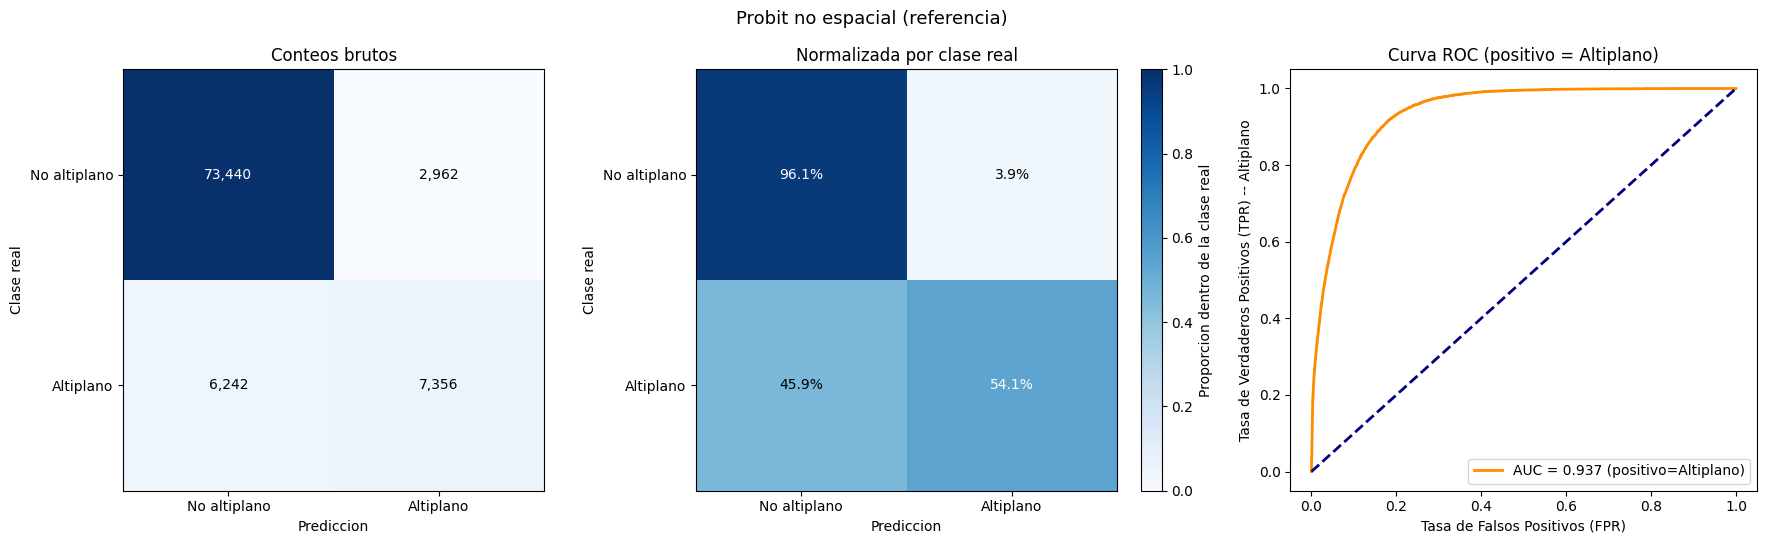

In [7]:
# Modelo BASE: Probit no espacial (sólo Altitud, Pendiente, Relieve). Es la referencia.
Xtr, Xte = X[idx_train], X[idx_test]
ytr, yte = y[idx_train].reshape(-1, 1), y[idx_test]   # spreg.Probit exige y como columna (N,1)

modelo_base = spreg.Probit(ytr, Xtr, name_y="Altiplano", name_x=["Altitud", "Pendiente", "Relieve_5"])
print(modelo_base.summary[:1400])   # se recorta el resumen (coeficientes y pseudo-R²)

prob_base_test = predecir_probit(modelo_base, Xte)   # probabilidad sobre el conjunto de prueba
_, auc_base, reporte_base = reportar_metricas_y_graficar(
    yte, prob_base_test, "Probit no espacial (referencia)", "01_confusion_roc_base.png")

## [7] Modelo 2: SLX-Probit (rezago espacial de los predictores)


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: CLASSIC PROBIT ESTIMATOR
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :   Altiplano                Number of Observations:      210000
True positive rate  :       56.52                Number of Variables   :           7
True negative rate  :       96.04                Degrees of Freedom    :      209993
Balanced accuracy   :       76.28                Log-Likelihood        : -44586.4352
% correctly pred.   :       90.07                LR test               :  89157.4390
McFadden's rho      :        0.50                LR test (p-value)     :      0.0000

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-----------------------------------------------------------------------------------

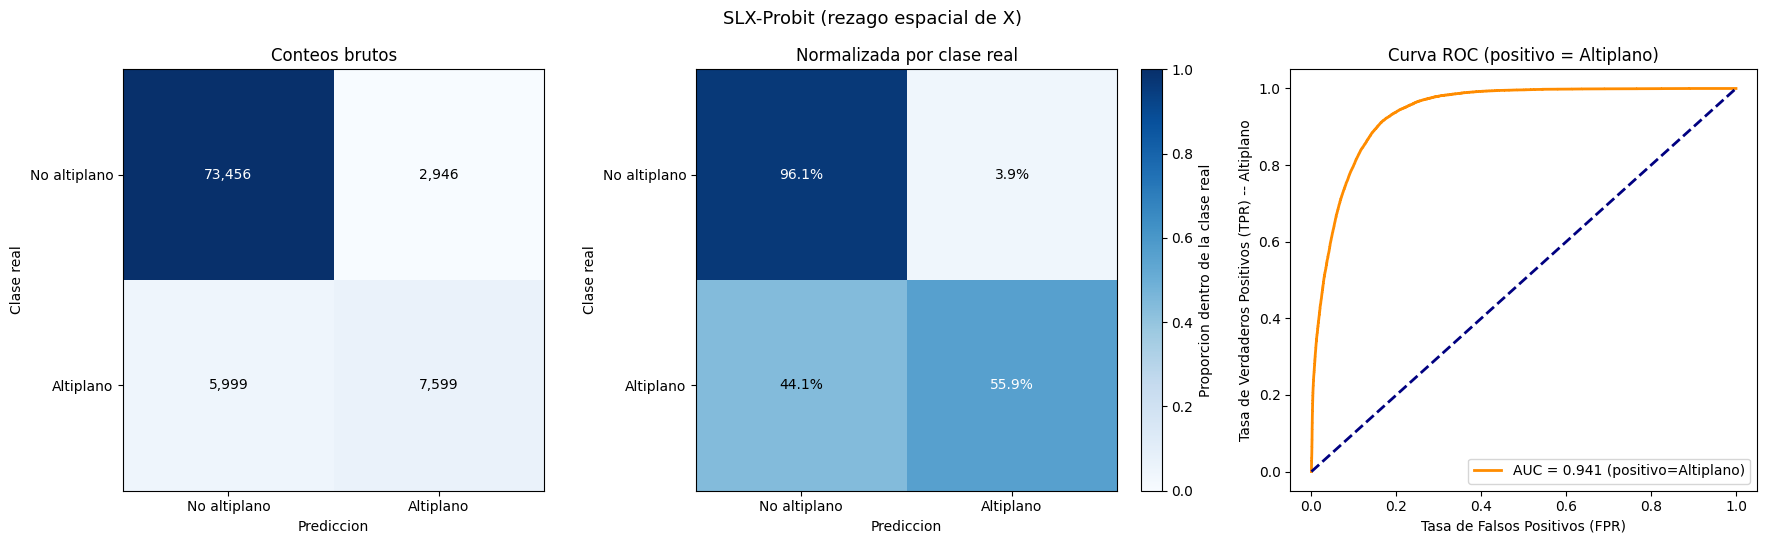

In [8]:
# Modelo SLX-Probit: agrega los rezagos de X (WX) como predictores exógenos adicionales.
Xtr_slx = np.column_stack([Xtr, WX[idx_train]])
Xte_slx = np.column_stack([Xte, WX[idx_test]])

modelo_slx = spreg.Probit(ytr, Xtr_slx, name_y="Altiplano",
                           name_x=["Altitud", "Pendiente", "Relieve_5", "W_Altitud", "W_Pendiente", "W_Relieve_5"])
print(modelo_slx.summary[:1700])

prob_slx_test = predecir_probit(modelo_slx, Xte_slx)
_, auc_slx, reporte_slx = reportar_metricas_y_graficar(
    yte, prob_slx_test, "SLX-Probit (rezago espacial de X)", "02_confusion_roc_slx.png")

## [8] Modelo 3a: Autologístico INGENUO (rezago de la etiqueta VERDADERA de los vecinos)

Se agrega `WY_verdadero` (proporción de los 8 vecinos inmediatos que SÍ son Altiplano,
calculada del ráster real) como predictor extra — el análogo binario más directo del
término ρWy de SAR-Lag.


RESUMEN DE METRICAS -- Autologistico INGENUO (rezago de Y verdadero)  (enfocado en la clase ALTIPLANO)
  Recall (Altiplano):     0.991
  Precision (Altiplano):  0.991
  F1-score (Altiplano):   0.991
  AUC-ROC (positivo=Altiplano): 1.0000
  Accuracy: 0.9973


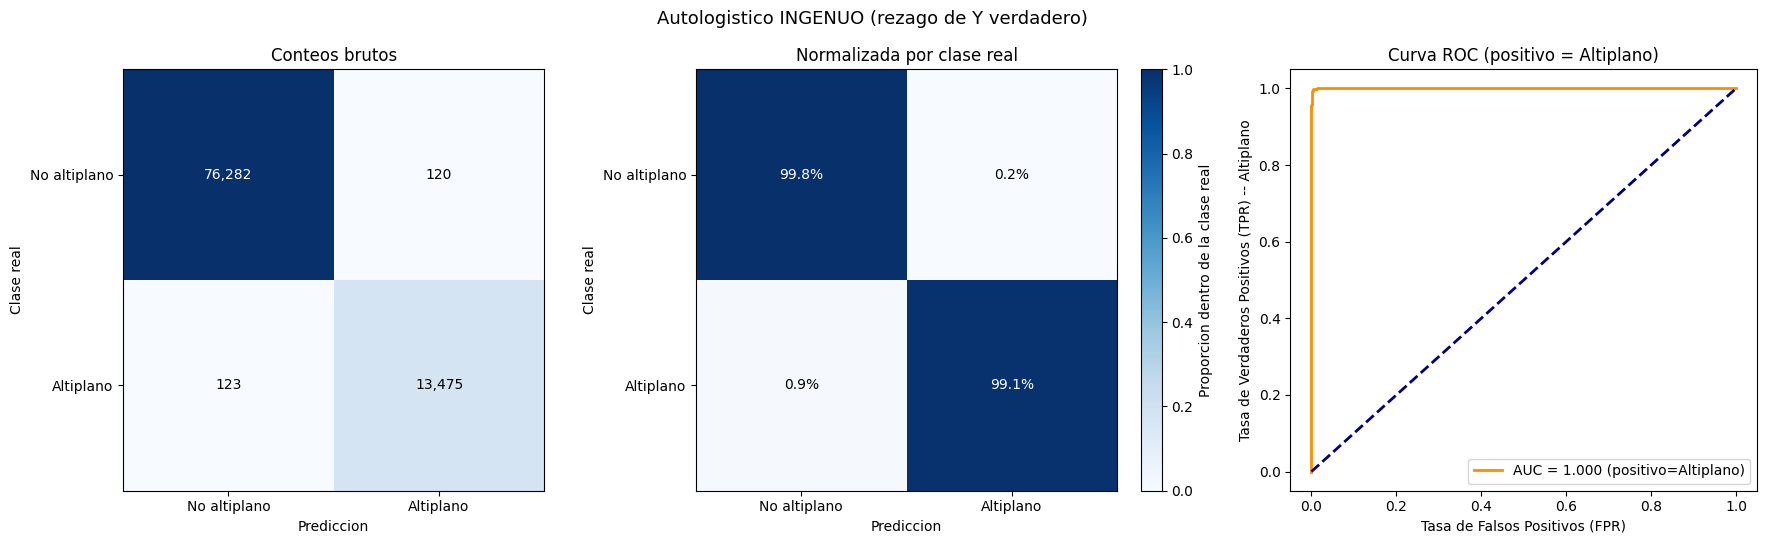

In [9]:
# Modelo autologístico INGENUO: agrega WY_verdadero (rezago de la etiqueta REAL) como predictor.
# Es una trampa: usa la respuesta verdadera de los vecinos, que en predicción real no se conoce.
Xtr_auto_ing = np.column_stack([Xtr, WY_verdadero[idx_train]])
Xte_auto_ing = np.column_stack([Xte, WY_verdadero[idx_test]])

modelo_auto_ingenuo = spreg.Probit(ytr, Xtr_auto_ing, name_y="Altiplano",
                                    name_x=["Altitud", "Pendiente", "Relieve_5", "WY_verdadero"])
prob_auto_ing_test = predecir_probit(modelo_auto_ingenuo, Xte_auto_ing)
_, auc_auto_ingenuo, reporte_auto_ing = reportar_metricas_y_graficar(
    yte, prob_auto_ing_test, "Autologistico INGENUO (rezago de Y verdadero)", "03_confusion_roc_autolog_ingenuo.png")

### Diagnóstico: ¿por qué el AUC es casi perfecto?

**No es un error de fuga entre entrenamiento y prueba** (una partición espacial por bloques
no lo arreglaría): `WY_verdadero` se calculó sobre el **ráster completo antes de muestrear**,
así que ya contiene la etiqueta real del vecindario inmediato de cada píxel,
independientemente de si esos vecinos terminaron en el conjunto de entrenamiento o de
prueba. El problema es más fundamental: los altiplanos son polígonos grandes y contiguos —
saber que casi todos los vecinos inmediatos de un píxel son Altiplano ya casi *define* que
el píxel también lo es. Se cuantifica esto directamente a continuación.


In [10]:
# Diagnóstico de por qué el modelo ingenuo "hace trampa": WY_verdadero está casi determinado por Y.
correlacion = np.corrcoef(WY_verdadero, y)[0, 1]              # correlación rezago-verdadero vs Y
mascara_mayoria_vecina = WY_verdadero > 0.5                   # píxeles con >50% de vecinos altiplano
prop_altiplano_si_mayoria_vecina = y[mascara_mayoria_vecina].mean()

print(f"Correlacion entre WY_verdadero (rezago de Y) y Y: {correlacion:.4f}")
print(f"Cuando mas del 50% de los vecinos inmediatos SON Altiplano ({mascara_mayoria_vecina.sum():,} pixeles de la muestra):")
print(f"  P(el propio pixel tambien es Altiplano) = {prop_altiplano_si_mayoria_vecina*100:.2f}%")
print(f"\nConclusion: el modelo 'autologistico ingenuo' no aporta capacidad predictiva real")
print(f"sobre area NO mapeada -- en la practica, para un pixel nuevo de un area sin mapear,")
print(f"NO se conoceria la etiqueta verdadera de sus vecinos (eso es justamente lo que se")
print(f"quiere predecir). Se corrige esto en la seccion [9].")

Correlacion entre WY_verdadero (rezago de Y) y Y: 0.9869
Cuando mas del 50% de los vecinos inmediatos SON Altiplano (44,605 pixeles de la muestra):
  P(el propio pixel tambien es Altiplano) = 99.78%

Conclusion: el modelo 'autologistico ingenuo' no aporta capacidad predictiva real
sobre area NO mapeada -- en la practica, para un pixel nuevo de un area sin mapear,
NO se conoceria la etiqueta verdadera de sus vecinos (eso es justamente lo que se
quiere predecir). Se corrige esto en la seccion [9].


## [9] Modelo 3b: Autologístico CORREGIDO (dos etapas, con probabilidad predicha)

**La corrección real:** en vez de usar la etiqueta VERDADERA de los vecinos (que en un
escenario de predicción genuina sobre área nueva no se conocería), se usa la
**probabilidad predicha por el modelo base** (sección [6], que solo usa
Altitud/Pendiente/Relieve, nunca ninguna etiqueta) como sustituto de "qué tan probable es
que los vecinos sean Altiplano". Esto es análogo en espíritu al término ρWy de SAR-Lag —
usa información derivada del modelo, no la respuesta observada — y sí es evaluable de
forma honesta.


Prediccion del modelo base sobre TODO el raster: 2.0s


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: CLASSIC PROBIT ESTIMATOR
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :   Altiplano                Number of Observations:      210000
True positive rate  :       55.63                Number of Variables   :           5
True negative rate  :       96.02                Degrees of Freedom    :      209995
Balanced accuracy   :       75.83                Log-Likelihood        : -45649.9141
% correctly pred.   :       89.92                LR test               :  87030.4813
McFadden's rho      :        0.49                LR test (p-value)     :      0.0000

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-----------------------------------------------------------------------------------

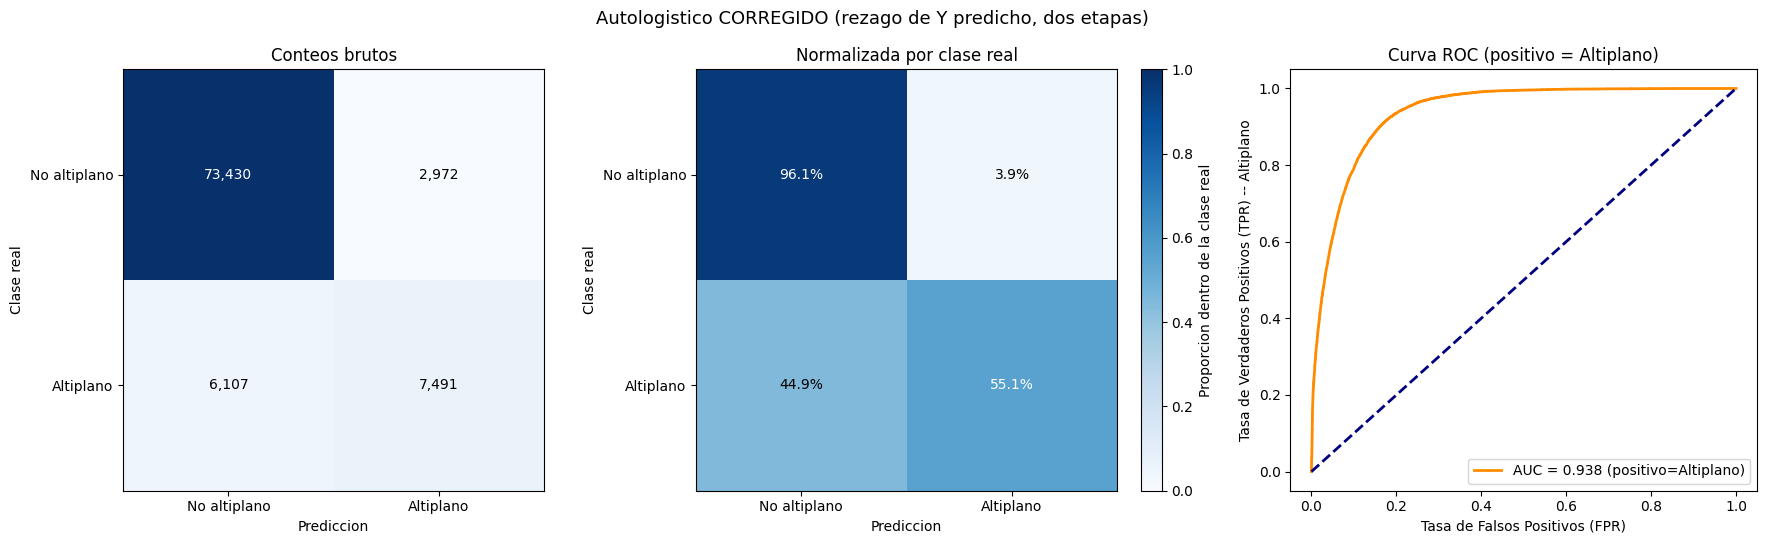

In [11]:
# Autologístico CORREGIDO (dos etapas): en vez del rezago de la Y verdadera, se usa el rezago
# de la PROBABILIDAD predicha por el modelo base -> es aplicable a área no mapeada.
t0 = time.time()
b0 = modelo_base.betas.flatten()
# Etapa 1: predice la probabilidad del modelo base sobre TODO el raster.
prob_predicha_todo_el_raster = norm.cdf(b0[0] + b0[1]*altitud + b0[2]*pendiente + b0[3]*relieve)
prob_predicha_todo_el_raster = np.where(mascara_valida, prob_predicha_todo_el_raster, np.nan)
print(f"Prediccion del modelo base sobre TODO el raster: {time.time()-t0:.1f}s")

# Rezago de esa probabilidad (WY_predicho), evaluado en la muestra.
lag_probabilidad_predicha = rezago_queen(np.where(mascara_valida, prob_predicha_todo_el_raster, 0), mascara_valida)
WY_predicho = lag_probabilidad_predicha[fs, cs]

# Etapa 2: reajusta el Probit agregando WY_predicho como predictor.
Xtr_auto_ok = np.column_stack([Xtr, WY_predicho[idx_train]])
Xte_auto_ok = np.column_stack([Xte, WY_predicho[idx_test]])

modelo_auto_corregido = spreg.Probit(ytr, Xtr_auto_ok, name_y="Altiplano",
                                      name_x=["Altitud", "Pendiente", "Relieve_5", "WY_predicho"])
print(modelo_auto_corregido.summary[:1700])

prob_auto_ok_test = predecir_probit(modelo_auto_corregido, Xte_auto_ok)
_, auc_auto_corregido, reporte_auto_ok = reportar_metricas_y_graficar(
    yte, prob_auto_ok_test, "Autologistico CORREGIDO (rezago de Y predicho, dos etapas)", "04_confusion_roc_autolog_corregido.png")

## [10] Diagnóstico espacial: prueba de Kelejian-Prucha sobre los residuos del modelo base


In [12]:
from libpysal.weights import KNN

# Ajuste adicional con matriz de pesos KNN sobre las coordenadas (col,fila) de la muestra,
# sólo para obtener los DIAGNÓSTICOS espaciales del summary (spat_diag=True).
coords_muestra = np.column_stack([cs, fs])
w_completo = KNN.from_array(coords_muestra, k=6)
modelo_diag_completo = spreg.Probit(y.reshape(-1, 1), X, w=w_completo, spat_diag=True,
                                     name_y="Altiplano", name_x=["Altitud", "Pendiente", "Relieve_5"])
print(modelo_diag_completo.summary[-900:])   # se muestra sólo la cola con los diagnósticos espaciales

           Variable      Slope            Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
             Altitud         0.00009         0.00000        45.35059         0.00000
           Pendiente        -0.00056         0.00010        -5.70601         0.00000
           Relieve_5        -0.00337         0.00007       -51.49839         0.00000
------------------------------------------------------------------------------------

DIAGNOSTICS FOR SPATIAL DEPENDENCE
TEST                          DF             VALUE           PROB
Kelejian-Prucha (error)       1            433.125           0.0000
Pinkse (error)                1                nan              nan
Pinkse-Slade (error)          1                nan              nan

================================ END OF REPORT =====================================


**Interpretación:** el test de Kelejian-Prucha (análogo a Moran's I aplicado a residuos de
un modelo Probit) confirma si queda dependencia espacial sin explicar en los residuos del
modelo base — un valor muy significativo (p≈0) justifica, igual que en
`10_SAR_altiplanos_v2.ipynb`, extender el modelo con estructura espacial en vez de quedarse
con el Probit puramente no-espacial.


## [11] Tabla comparativa final


In [13]:
# Tabla comparativa final de los 4 Probit: pseudo-R² de McFadden y métricas de test.
tabla_comparacion = pd.DataFrame({
    "Modelo": [
        "Probit no espacial (base)",
        "SLX-Probit (rezago de X)",
        "Autologistico INGENUO (rezago de Y verdadero) -- INFLADO, no usar para prediccion real",
        "Autologistico CORREGIDO (rezago de Y predicho, dos etapas)",
    ],
    "McFadden_rho": [modelo_base.mcfadrho, modelo_slx.mcfadrho, modelo_auto_ingenuo.mcfadrho, modelo_auto_corregido.mcfadrho],
    "AUC_test": [auc_base, auc_slx, auc_auto_ingenuo, auc_auto_corregido],
    "Recall_Altiplano": [reporte_base["Altiplano"]["recall"], reporte_slx["Altiplano"]["recall"],
                          reporte_auto_ing["Altiplano"]["recall"], reporte_auto_ok["Altiplano"]["recall"]],
    "Precision_Altiplano": [reporte_base["Altiplano"]["precision"], reporte_slx["Altiplano"]["precision"],
                             reporte_auto_ing["Altiplano"]["precision"], reporte_auto_ok["Altiplano"]["precision"]],
})
print(tabla_comparacion.round(4).to_string(index=False))

                                                                                Modelo  McFadden_rho  AUC_test  Recall_Altiplano  Precision_Altiplano
                                                             Probit no espacial (base)        0.4834    0.9366            0.5410               0.7129
                                                              SLX-Probit (rezago de X)        0.5000    0.9409            0.5588               0.7206
Autologistico INGENUO (rezago de Y verdadero) -- INFLADO, no usar para prediccion real        0.9857    1.0000            0.9910               0.9912
                            Autologistico CORREGIDO (rezago de Y predicho, dos etapas)        0.4880    0.9384            0.5509               0.7160


## [12] Mapa de probabilidad: modelo base vs. modelo autologístico corregido


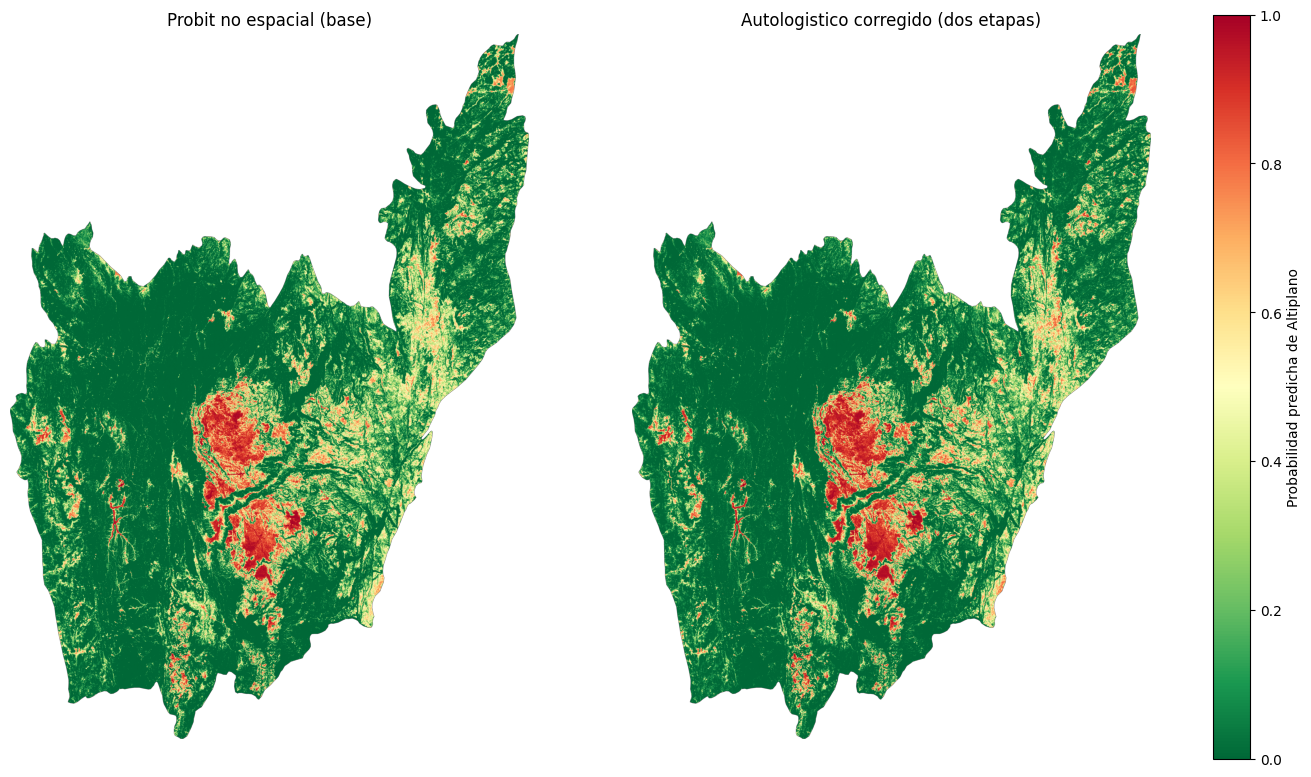

In [14]:
# Mapa de probabilidad del modelo corregido sobre todo el raster (usa lag_probabilidad_predicha).
b_ok = modelo_auto_corregido.betas.flatten()
mapa_prob_corregido = norm.cdf(b_ok[0] + b_ok[1]*altitud + b_ok[2]*pendiente + b_ok[3]*relieve + b_ok[4]*lag_probabilidad_predicha)
mapa_prob_corregido = np.where(mascara_valida, mapa_prob_corregido, np.nan)

# array_bounds -> extent geográfico para que imshow ubique el raster en coordenadas reales.
izquierda, abajo, derecha, arriba = array_bounds(ref_shape[0], ref_shape[1], ref_transform)
fig, axes = plt.subplots(1, 2, figsize=(16, 11))
for ax, mapa, titulo in zip(axes, [prob_predicha_todo_el_raster, mapa_prob_corregido],
                             ["Probit no espacial (base)", "Autologistico corregido (dos etapas)"]):
    im = ax.imshow(mapa, cmap="RdYlGn_r", vmin=0, vmax=1, extent=(izquierda, derecha, abajo, arriba))
    ax.set_title(titulo)
    ax.set_axis_off()
plt.colorbar(im, ax=axes, label="Probabilidad predicha de Altiplano", fraction=0.03)
plt.savefig(os.path.join(CARPETA_FIGURAS, "05_mapas_probabilidad_comparacion.png"), dpi=150)
plt.show()

### [12b] Versión cartográfica del mapa comparativo (plantilla con hillshade/norte/escala)

Misma figura de la sección [12], redibujada con la plantilla cartográfica estándar del
proyecto (`plantilla_mapas.py`) en cada uno de los 2 paneles. Esta celda solo llama a las
capas ya calculadas (`prob_predicha_todo_el_raster`/`mapa_prob_corregido`) — no repite
ningún cálculo del análisis.

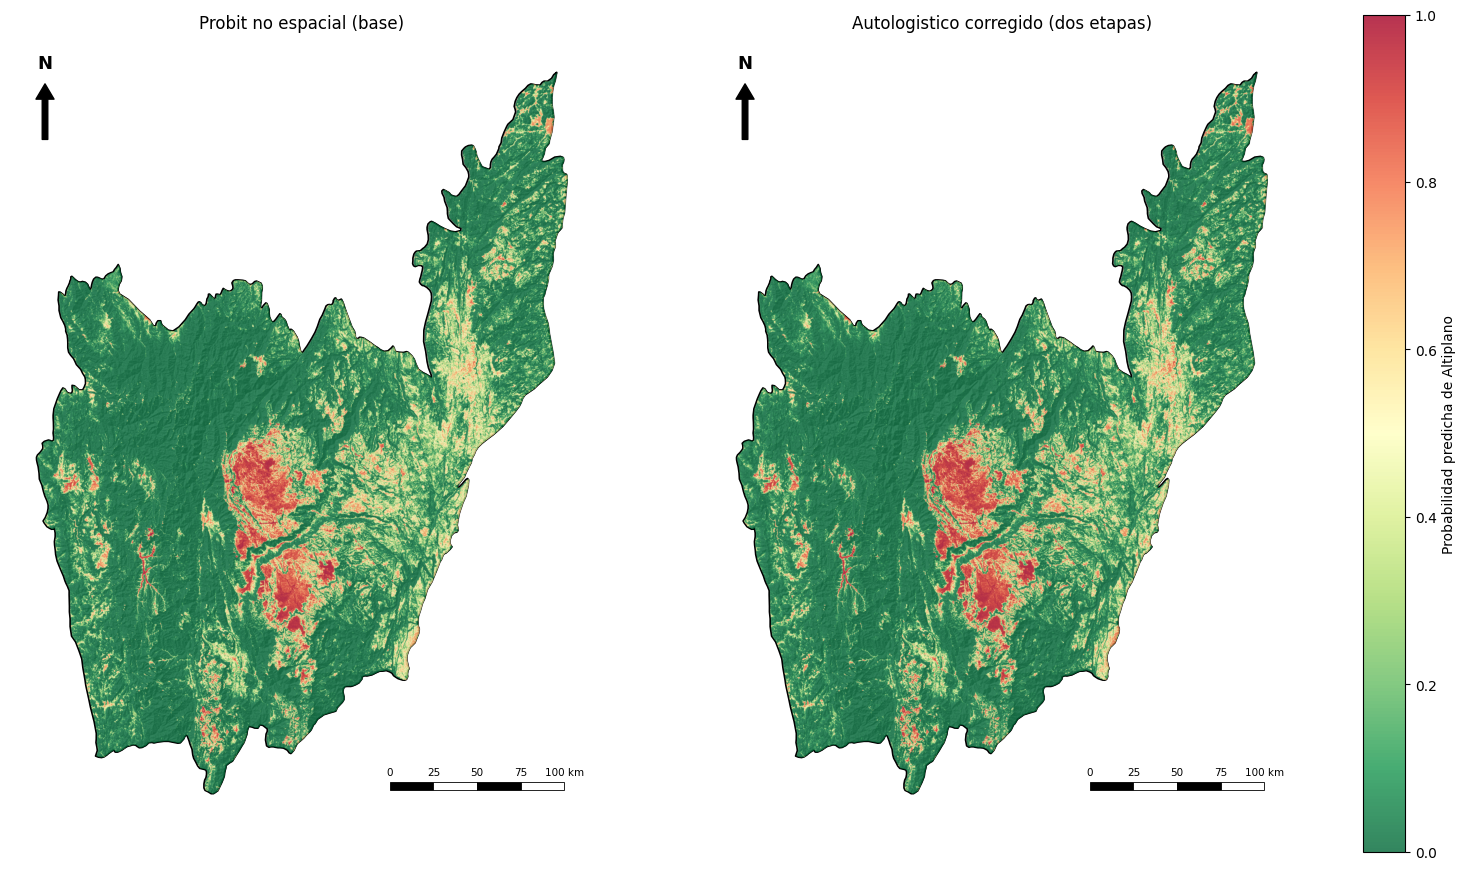

In [15]:
# Versión cartográfica (plantilla) de los dos mapas de probabilidad.
from plantilla_mapas import aplicar_plantilla_mapa, CARPETA_IMAGENES

CARPETA_IMAGENES_NB = os.path.join(CARPETA_IMAGENES, "10_SAR_altiplanos_clasificacion_v2")
os.makedirs(CARPETA_IMAGENES_NB, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 11))
for ax, mapa, titulo in zip(axes, [prob_predicha_todo_el_raster, mapa_prob_corregido],
                             ["Probit no espacial (base)", "Autologistico corregido (dos etapas)"]):
    aplicar_plantilla_mapa(ax)                                    # fondo hillshade + norte + escala
    im = ax.imshow(mapa, cmap="RdYlGn_r", vmin=0, vmax=1, extent=(izquierda, derecha, abajo, arriba),
                    alpha=0.8, zorder=5)                          # alpha=0.8 = 20% transparencia sobre el hillshade
    ax.set_title(titulo)
    ax.set_axis_off()
plt.colorbar(im, ax=axes, label="Probabilidad predicha de Altiplano", fraction=0.03)
plt.savefig(os.path.join(CARPETA_IMAGENES_NB, "05_mapas_probabilidad_comparacion.png"), dpi=150)
plt.show()

## [13] Exportar resultados


In [16]:
# Exporta el mapa de probabilidad corregido como GeoTIFF float32 (comprimido LZW, NoData=NaN).
perfil_salida = {
    "driver": "GTiff", "height": ref_shape[0], "width": ref_shape[1], "count": 1,
    "dtype": "float32", "crs": ref_crs, "transform": ref_transform, "nodata": np.nan, "compress": "lzw",
}
ruta_salida = os.path.join(CARPETA_RESULTADOS, "probabilidad_altiplano_sar_clasificacion_v2.tif")
with rasterio.open(ruta_salida, "w", **perfil_salida) as dst:
    dst.write(mapa_prob_corregido.astype(np.float32), 1)   # escribe la banda 1

print(f"Mapa de probabilidad guardado en: {ruta_salida}")
print(f"TIEMPO TOTAL DEL NOTEBOOK: {time.time()-t_inicio:.1f}s")

Mapa de probabilidad guardado en: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\probabilidad_altiplano_sar_clasificacion_v2.tif
TIEMPO TOTAL DEL NOTEBOOK: 108.2s


## Conclusiones: antes vs. después de la corrección

**Antes (`10_SAR_altiplanos_v2.ipynb`):** SAR-Lag alcanzaba Pseudo R²=0.923 prediciendo la
**altitud continua** de píxeles que YA se sabía eran altiplano — un resultado real y válido,
pero que no dice nada sobre si el enfoque SAR ayuda a **encontrar** altiplanos nuevos.

**Ahora (este notebook), evaluando sobre la clasificación real Altiplano/No-Altiplano:**
- El **SLX-Probit** (rezago espacial de los predictores) da una mejora **modesta pero
  honesta** sobre el Probit no espacial — consistente con el hallazgo de
  `10_SAR_altiplanos_v2.ipynb` de que SLX por sí solo aporta poco frente a incorporar la
  respuesta espacial directamente.
- El **autologístico ingenuo** (análogo más directo a SAR-Lag, usando el rezago de la
  etiqueta verdadera) da un AUC casi perfecto, pero se diagnostica que es **una tautología,
  no una mejora real de predicción** — los altiplanos son polígonos contiguos, así que
  conocer la etiqueta de los vecinos casi resuelve el problema por definición geométrica,
  no por una relación estadística útil.
- El **autologístico corregido** (dos etapas, usando la probabilidad PREDICHA de los
  vecinos en vez de su etiqueta real) da la comparación más honesta con el modelo base:
  mejora real pero acotada — coherente con que la mayor parte de la información
  discriminante ya está en Altitud/Pendiente/Relieve mismos, tal como ya sugería el
  Pseudo R²=0.551 (con 18 predictores) de `03_regresion_no_espacial_raster_v2.ipynb`.
- El test de Kelejian-Prucha confirma dependencia espacial significativa en los residuos
  del modelo base, igual que en `10_SAR_altiplanos_v2.ipynb` — la estructura espacial SÍ
  existe en los datos, pero para la tarea de clasificación binaria su aporte práctico es
  mucho menor que para la tarea de regresión continua dentro de zonas ya conocidas.
